# Symmetry-separated NUTS inference for the MWA AEE beam

This notebook develops a symmetry-aware alternative to the expensive SMC inference.

The previous SMC exploration established four important facts:

1. the complex dipole-gain posterior contains two well-separated modes;
2. the modes are related by a conjugate + \(180^\circ\)-rotation symmetry of the
   effective complex dipole coefficients;
3. the statistic \(S(g)\) cleanly separates the two branches;
4. NUTS samples either branch efficiently **when initialized inside the local
   posterior mode**.

The current goal is therefore not to rediscover the modes with SMC. It is to build a
cheaper workflow:

$$
\text{generic branch seed}
\rightarrow
\text{MAP}_{+}
\rightarrow
\begin{cases}
\text{NUTS}_{+},\\
T(\text{MAP}_{+}) \rightarrow \text{MAP}_{-} \rightarrow \text{NUTS}_{-},
\end{cases}
$$

followed by a Laplace approximation to estimate the relative posterior mass of the
two branches.

SMC is retained below only as a **temporary validation tool** while this replacement
workflow is developed.

## 1. Imports and configuration

In [1]:
from pathlib import Path
import re

import numpy as np
import healpy as hp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import cmasher as cmr
from matplotlib.colors import ListedColormap

from embers_passes import PassFile, chunk_passes, chunks_to_healpix_counts
from mwa_jaxbeam import aee_137mhz as aee

colors = cmr.pride(np.linspace(0.1, 0.8, 256))
prd = ListedColormap(colors, name="pride")
prd.set_under("white")

wfr_lin = cmr.get_sub_cmap(cmr.wildfire, 0.5, 1.0).with_extremes(under="w")

In [2]:
INPUT_PATH = Path("../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5")

POINTING = 0
CHUNK_INDEX = 0
CHUNK_DAYS = 200.0
NSIDE = 32
MIN_PIXEL_COUNTS = 3

N_DIPOLES = 16
dipoles = np.arange(N_DIPOLES)

# Priors retained from the SMC experiments.
DIRICHLET_ALPHA = 10.0
PHASE_PRIOR_STD_DEG = 10.0
PHASE_PRIOR_STD_RAD = np.deg2rad(PHASE_PRIOR_STD_DEG)
PHASE_KAPPA = 1.0 / PHASE_PRIOR_STD_RAD**2

print("Input:", INPUT_PATH)
print("NSIDE:", NSIDE)
print("Minimum samples per HEALPix pixel:", MIN_PIXEL_COUNTS)

Input: ../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5
NSIDE: 32
Minimum samples per HEALPix pixel: 3


In [3]:
def infer_tile_pol(path):
    match = re.search(r"(S\d{2})(XX|YY)", path.name, re.IGNORECASE)
    if match is None:
        raise ValueError(f"Could not infer tile/pol from {path.name!r}.")
    tile, pol = match.group(1).upper(), match.group(2).upper()
    return tile, pol, {"XX": 0, "YY": 1}[pol]

tile, pol_name, POL = infer_tile_pol(INPUT_PATH)
tilepol = f"{tile}{pol_name}"

print("Tile/polarization:", tilepol)
print("AEE polarization index:", POL)

Tile/polarization: S06XX
AEE polarization index: 0


## 2. Load the satellite beam and define the likelihood pixels

The data construction follows `run_smc.py`, but no SMC products are loaded.

For each HEALPix pixel we use the median satellite measurement as the beam estimate.
The observational uncertainty is

$$
\sigma_{\rm obs}
=
\sqrt{
{\rm MAD}^2
+
\sigma_{\rm median}^2
}.
$$

Only pixels that

- lie above the horizon,
- contain at least `MIN_PIXEL_COUNTS` contributing measurements,
- have finite data and uncertainty, and
- have positive finite nominal AEE power

are included in the likelihood.

In [4]:
passes = PassFile(INPUT_PATH).read_passes(pointing=POINTING)

chunks, bin_edges, bin_centers = chunk_passes(
    passes,
    chunk_sec=CHUNK_DAYS * 86400,
)

if CHUNK_INDEX >= len(chunks):
    raise IndexError(
        f"Chunk {CHUNK_INDEX} requested; only {len(chunks)} chunks exist."
    )

median_maps, count_maps, mad_maps, median_sem_maps = chunks_to_healpix_counts(
    passes,
    chunks,
    decimate=1,
    nside=NSIDE,
)

data_map = np.asarray(
    median_maps[CHUNK_INDEX],
    dtype=np.float32,
)
count_map = np.asarray(
    count_maps[CHUNK_INDEX],
)
error_map = np.sqrt(
    np.asarray(mad_maps[CHUNK_INDEX], dtype=np.float32) ** 2
    + np.asarray(median_sem_maps[CHUNK_INDEX], dtype=np.float32) ** 2
).astype(np.float32)

N_PIXELS = hp.nside2npix(NSIDE)
pixel_indices = np.arange(N_PIXELS)
za_hpx, az_hpx = hp.pix2ang(NSIDE, pixel_indices)

sampled_visible = (
    (za_hpx <= np.pi / 2)
    & (count_map >= MIN_PIXEL_COUNTS)
)

reference_power = np.full(N_PIXELS, np.nan, dtype=np.float32)
reference_power[sampled_visible] = np.asarray(
    aee.power(
        az_rad=az_hpx[sampled_visible],
        za_rad=za_hpx[sampled_visible],
        normalize=True,
    )[POL],
    dtype=np.float32,
)

valid = (
    sampled_visible
    & np.isfinite(data_map)
    & np.isfinite(error_map)
    & (error_map > 0)
    & np.isfinite(reference_power)
    & (reference_power > 0)
)

comparison_indices = np.flatnonzero(valid)

if comparison_indices.size == 0:
    raise ValueError("No valid comparison pixels.")

observed_db = np.asarray(
    data_map[comparison_indices],
    dtype=np.float32,
)
observed_sigma_db = np.asarray(
    error_map[comparison_indices],
    dtype=np.float32,
)

print(f"HEALPix pixels:      {N_PIXELS}")
print(f"Comparison pixels:   {comparison_indices.size}")
print(f"Median uncertainty:  {np.median(observed_sigma_db):.4f} dB")

HEALPix pixels:      12288
Comparison pixels:   6072
Median uncertainty:  0.3854 dB


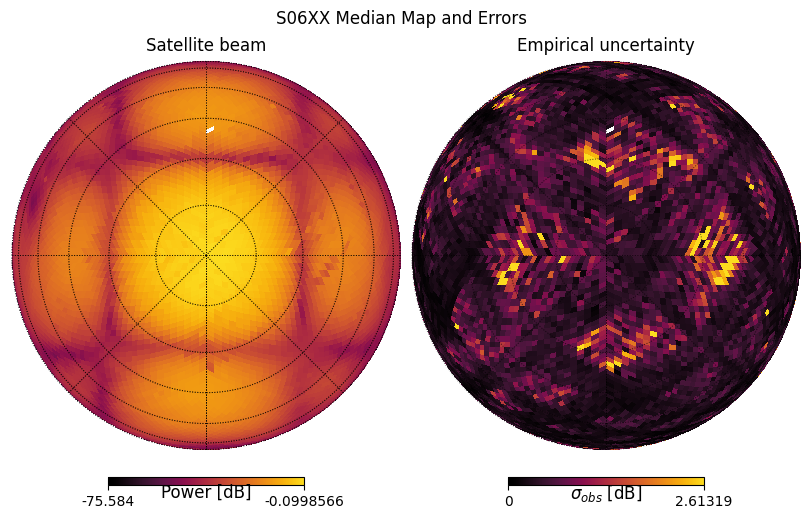

In [5]:
def plot_healpix_map(
    healpix_map,
    *,
    fig,
    sub,
    title="",
    unit="",
    vmin=None,
    vmax=None,
    cmap=None,
    badcolor="whitesmoke",
):
    hp.orthview(
        map=np.asarray(healpix_map),
        fig=fig,
        sub=sub,
        rot=(0, 90, 180),
        half_sky=True,
        min=vmin,
        max=vmax,
        title=title,
        unit=unit,
        badcolor=badcolor,
        cmap=cmap,
        notext=True,
    )

    hp.graticule(
        dpar=15,
        dmer=45,
        ls=":",
        lw=0.7,
        alpha=0.7,
    )


fig = plt.figure(figsize=(8, 5.3))

plot_healpix_map(
    data_map,
    fig=fig,
    sub=(1, 2, 1),
    title="Satellite beam",
    unit="Power [dB]",
    cmap=wfr_lin,
)

plot_healpix_map(
    error_map,
    fig=fig,
    sub=(1, 2, 2),
    title="Empirical uncertainty",
    unit=r"$\sigma_{obs}$ [dB]",
    vmin=0,
    vmax=np.nanpercentile(error_map, 99),
    cmap=wfr_lin,
)

fig.suptitle(f"{tilepol} Median Map and Errors")
plt.show()

## 3. Reconstruct the AEE forward model

The refactored AEE model separates two different operations:

$$
\text{dipole flags}
\rightarrow
\text{coupled current solve}
\rightarrow
\text{complex dipole gains}
\rightarrow
\text{array factor}.
$$

The nominal coupled currents are calculated from

$$
\mathbf I
=
\mathbf Z^{-1}\mathbf V,
$$

where the unflagged driven ports have unit voltage and flagged ports have zero
voltage.

The inferred complex gains are **not** used in this solve. They are applied afterward
to the complete coupled response associated with each driven dipole/feed.

For an XX fit we infer the 16 X-feed gains while keeping all Y-feed gains equal to
unity. For a YY fit the roles are reversed.

In [6]:
visible_indices = np.flatnonzero(sampled_visible)

visible_lookup = np.full(
    N_PIXELS,
    -1,
    dtype=np.int32,
)
visible_lookup[visible_indices] = np.arange(
    visible_indices.size,
    dtype=np.int32,
)

comparison_visible_indices = visible_lookup[comparison_indices]

if np.any(comparison_visible_indices < 0):
    raise ValueError(
        "At least one comparison pixel lies outside the sampled visible set."
    )

az_visible = jnp.asarray(
    az_hpx[sampled_visible],
    dtype=jnp.float32,
)
za_visible = jnp.asarray(
    za_hpx[sampled_visible],
    dtype=jnp.float32,
)
comparison_visible_indices_jax = jnp.asarray(
    comparison_visible_indices,
    dtype=jnp.int32,
)


@jax.jit
def predict_beam_db(dipole_gains_pol):
    fixed = jnp.ones(
        N_DIPOLES,
        dtype=jnp.complex64,
    )

    dipole_gains_pol = dipole_gains_pol.astype(
        jnp.complex64
    )

    dipole_gains = (
        jnp.stack([dipole_gains_pol, fixed])
        if POL == 0
        else jnp.stack([fixed, dipole_gains_pol])
    )

    power = aee.power(
        az_rad=az_visible,
        za_rad=za_visible,
        dipole_gains=dipole_gains,
        normalize=True,
    )[POL, comparison_visible_indices_jax]

    power = jnp.maximum(
        power,
        jnp.finfo(power.dtype).tiny,
    )

    return 10 * jnp.log10(power)


nominal_gains = jnp.ones(
    N_DIPOLES,
    dtype=jnp.complex64,
)

nominal_model_db = np.asarray(
    predict_beam_db(nominal_gains),
    dtype=float,
)

nominal_residual_db = observed_db - nominal_model_db

print("Forward-model output:", nominal_model_db.shape)
print(
    "Nominal residual RMS:",
    f"{np.sqrt(np.mean(nominal_residual_db**2)):.3f} dB",
)

Forward-model output: (6072,)
Nominal residual RMS: 7.889 dB


## 4. Effective dipole coefficients

For one fitted polarization, each physical dipole contributes two nominal complex
AEE current terms to the corresponding array factor:

- $I_n^{\rm dir}$: the current contribution from driving the fitted feed;
- $I_n^{\rm cross}$: the contribution on the same port polarization generated by
  driving the other feed through mutual coupling.

For example, in an XX fit,

$$
I_n^{\rm dir}=I_{X\leftarrow X,n},
\qquad
I_n^{\rm cross}=I_{X\leftarrow Y,n}.
$$

The inferred gain $g_n$ multiplies the directly driven response, while the gain of
the other feed is fixed to unity. The total complex coefficient contributed by
dipole $n$ is therefore

$$
c_n(g)
=
g_n I_n^{\rm dir}
+
I_n^{\rm cross}.
$$

This $c_n$, rather than $g_n$ alone, is the complex coefficient that enters the
coherent array sum.

In [7]:
currents = jnp.asarray(aee.port_currents())

# currents has shape:
#     (port polarization, driven feed, dipole)
if POL == 0:
    i_direct = currents[0, 0]
    i_cross = currents[0, 1]
elif POL == 1:
    i_direct = currents[1, 1]
    i_cross = currents[1, 0]
else:
    raise ValueError(f"Unexpected POL={POL}")


@jax.jit
def effective_coefficients(dipole_gains_pol):
    """Return c_n = g_n I_direct,n + I_cross,n."""
    return (
        dipole_gains_pol.astype(jnp.complex64) * i_direct
        + i_cross
    )


nominal_coefficients = effective_coefficients(nominal_gains)

print("Nominal coefficient shape:", nominal_coefficients.shape)
print("Direct-current dtype:", i_direct.dtype)
print("Cross-current dtype:", i_cross.dtype)

Nominal coefficient shape: (16,)
Direct-current dtype: complex64
Cross-current dtype: complex64


# Part I — Origin of the two-mode degeneracy

## 5. Conjugate-rotation symmetry

For the fitted polarization, write the electric-field array factor as

$$
F(\mathbf{k})
=
\sum_{n=0}^{15}
c_n
e^{i\mathbf{k}\cdot\mathbf{r}_n}.
$$

The MWA $4\times4$ tile is symmetric under a $180^\circ$ rotation. With the
dipole numbering used here, that rotation exchanges

$$
0\leftrightarrow15,\qquad
1\leftrightarrow14,\qquad
2\leftrightarrow13,\qquad
\ldots
$$

or simply

$$
n\leftrightarrow15-n.
$$

Now construct a second set of complex coefficients by rotating the tile by
$180^\circ$ and taking the complex conjugate:

$$
c'_n=c^*_{15-n}.
$$

The corresponding electric field is

$$
F'(\mathbf{k})
=
\sum_{n=0}^{15}
c^*_{15-n}
e^{i\mathbf{k}\cdot\mathbf{r}_n}.
$$

Relabel the sum using

$$
m=15-n.
$$

If the coordinate origin is placed at the centre of the MWA tile, the rotated
dipole position satisfies

$$
\mathbf r_{15-m}=-\mathbf r_m.
$$

Therefore,

$$
F'(\mathbf{k})
=
\sum_{m=0}^{15}
c_m^*
e^{-i\mathbf{k}\cdot\mathbf r_m}.
$$

But

$$
F^*(\mathbf{k})
=
\left(
\sum_{m=0}^{15}
c_m
e^{i\mathbf{k}\cdot\mathbf r_m}
\right)^*
=
\sum_{m=0}^{15}
c_m^*
e^{-i\mathbf{k}\cdot\mathbf r_m}.
$$

Hence

$$
F'(\mathbf{k})=F^*(\mathbf{k}).
$$

The power beam is therefore unchanged:

$$
|F'(\mathbf{k})|^2
=
|F(\mathbf{k})|^2.
$$

Thus the two coefficient sets

$$
\{c_n\}
\qquad\text{and}\qquad
\{c^*_{15-n}\}
$$

produce the same ideal power beam.

In the real satellite data the symmetry need not be perfect: environmental and
instrumental asymmetries can make the two solutions have slightly different
likelihoods. Nevertheless, the conjugate-rotation relation explains why two
well-separated, closely related posterior modes appear.

### From coefficients back to dipole gains

The simple conjugate-rotation symmetry acts on the total coefficients $c_n$, not
directly on the inferred gains $g_n$.

Since

$$
c_n
=
g_n I_n^{\rm dir}
+
I_n^{\rm cross},
$$

a transformed coefficient $c'_n$ corresponds to

$$
g'_n
=
\frac{
c'_n-I_n^{\rm cross}
}{
I_n^{\rm dir}
}.
$$

When comparing transformed gains with the posterior, the inference convention
$\phi_0=0$ must also be respected. Multiplying all transformed coefficients by a
single common phase $e^{i\alpha}$ does not change the power beam:

$$
|e^{i\alpha}F|^2=|F|^2.
$$

The common phase can therefore be chosen so that the reconstructed dipole-0 gain is
real and positive, matching the phase-reference convention used by the inference.

The branch-separation statistic below does not depend on this common phase because it
uses only $|c_n|^2$.

# Part II — A statistic that separates the symmetry-related branches

## 6. Define $S(g)$

We would like a single scalar quantity that distinguishes the two
conjugate-rotation-related regions of parameter space.

The effective coefficient of dipole $n$ is

$$
c_n(g)
=
g_n I_n^{\rm dir}
+
I_n^{\rm cross}.
$$

Under conjugate rotation,

$$
c_n
\longrightarrow
c'_n
=
e^{i\alpha}c^*_{15-n}.
$$

The common phase and complex conjugation do not change the coefficient amplitudes:

$$
|c'_n|^2
=
|c_{15-n}|^2.
$$

We therefore define

$$
S(g)
=
\sum_{n=0}^{7}
\left(
|c_n(g)|^2
-
|c_{15-n}(g)|^2
\right).
$$

Equivalently,

$$
S(g)
=
\sum_{n=0}^{7}|c_n(g)|^2
-
\sum_{n=8}^{15}|c_n(g)|^2.
$$

Under conjugate rotation,

$$
\begin{aligned}
S(g')
&=
\sum_{n=0}^{7}
\left(
|c'_n|^2-|c'_{15-n}|^2
\right)\\
&=
\sum_{n=0}^{7}
\left(
|c_{15-n}|^2-|c_n|^2
\right)\\
&=
-S(g).
\end{aligned}
$$

Thus the two symmetry-related branches necessarily have opposite signs:

$$
S(g)>0
\qquad\longleftrightarrow\qquad
S(g')<0.
$$

The sign has no physical preference attached to it. It is simply a deterministic
label for the two branches.

The previous SMC exploration showed that, for the tested tile/polarizations, the two
posterior modes occupy opposite signs of $S(g)$ with essentially no posterior
support near $S(g)=0$. This motivates treating

$$
S(g)>0
\quad\text{and}\quad
S(g)<0
$$

as two separate inference problems.

In [8]:
PAIR_LEFT = jnp.arange(8)
PAIR_RIGHT = 15 - PAIR_LEFT


@jax.jit
def symmetry_statistic(dipole_gains_pol):
    """Return S(g) for one 16-element complex gain vector."""
    coefficients = effective_coefficients(dipole_gains_pol)

    return jnp.sum(
        jnp.abs(coefficients[PAIR_LEFT]) ** 2
        - jnp.abs(coefficients[PAIR_RIGHT]) ** 2
    )


nominal_s = float(symmetry_statistic(nominal_gains))

print(f"S(g=1): {nominal_s:.6e}")
print(
    "Nominal branch:",
    "positive" if nominal_s > 0 else "negative" if nominal_s < 0 else "boundary",
)

S(g=1): -1.194463e-11
Nominal branch: negative


In [9]:
# A direct numerical check of the sign-flip property at coefficient level.
# The common phase is irrelevant because S uses |c_n|^2.

test_coefficients = np.asarray(nominal_coefficients)
rotated_conjugate_coefficients = np.conj(test_coefficients[::-1])


def statistic_from_coefficients(coefficients):
    coefficients = np.asarray(coefficients)

    return np.sum(
        np.abs(coefficients[:8]) ** 2
        - np.abs(coefficients[15:7:-1]) ** 2
    )


s_original = statistic_from_coefficients(test_coefficients)
s_transformed = statistic_from_coefficients(rotated_conjugate_coefficients)

print(f"S(c):       {s_original:+.6e}")
print(f"S(T(c)):    {s_transformed:+.6e}")
print(f"S(T(c))+S:  {s_transformed + s_original:+.3e}")

S(c):       -1.193712e-11
S(T(c)):    +1.193712e-11
S(T(c))+S:  +0.000e+00


# Part III — Symmetry-separated NUTS

## 7. Intended branch posteriors

The full complex posterior can be decomposed into two branch-conditioned posteriors,

$$
p_+(g\mid D)
\propto
p(D\mid g)\,p(g)\,
\mathbf 1[S(g)>0],
$$

and

$$
p_-(g\mid D)
\propto
p(D\mid g)\,p(g)\,
\mathbf 1[S(g)<0].
$$

The scientific prior on the complex gains remains the same in both runs. The sign
condition does not claim that either branch is more physical; it prevents each NUTS
run from having to traverse the large low-probability region between the two modes.

The next development step is to choose a NUTS-friendly way of enforcing the branch
condition. A hard indicator is conceptually simple but introduces a discontinuous
boundary at \(S=0\). Since the SMC posteriors lie far from that boundary this may be
practical, but a smooth or explicitly constrained parameterization should be explored
before committing to the final implementation.

### Gain prior retained from the SMC model

For the complex model, the gain amplitudes are parameterized through a Dirichlet
distribution,

$$
\mathbf f
\sim
{\rm Dirichlet}(\alpha,\ldots,\alpha),
\qquad
a_n=16f_n,
$$

so that

$$
\sum_{n=0}^{15}a_n=16.
$$

Relative phases for dipoles $1,\ldots,15$ are given circular priors centred on zero,

$$
\phi_n\sim{\rm VonMises}(0,\kappa),
$$

with dipole 0 defining the phase reference,

$$
\phi_0=0.
$$

The complex gains are

$$
g_n=a_ne^{i\phi_n}.
$$

The branch condition $S(g)\gtrless0$ is an additional identifiability constraint on
the inference region, not a replacement for these physical priors.

# Part III — Branch-conditioned NumPyro model

## 7. One model, optionally restricted to one branch

The underlying scientific model is identical on both branches. We retain the same
Dirichlet amplitude prior and Von Mises phase prior used in the SMC analysis.

The optional `branch_sign` argument only restricts the allowed sign of \(S(g)\):

- `branch_sign=+1`: \(S(g)>0\);
- `branch_sign=-1`: \(S(g)<0\);
- `branch_sign=None`: unrestricted posterior.

The phase site is wrapped with `CircularReparam`, so the actual unconstrained HMC
coordinate is `relative_phase_unwrapped`.

In [10]:
import arviz as az
import numpyro
import numpyro.distributions as dist

from numpyro.handlers import reparam
from numpyro.infer import MCMC, NUTS, init_to_value
from numpyro.infer.reparam import CircularReparam


In [11]:
def build_branch_model(
    branch_sign=None,
    *,
    dirichlet_alpha=DIRICHLET_ALPHA,
    phase_kappa=PHASE_KAPPA,
):
    """Build the complex-gain model, optionally restricted by sign of S(g)."""
    if branch_sign not in (-1, 1, None):
        raise ValueError("branch_sign must be +1, -1, or None.")

    concentration = jnp.full(
        N_DIPOLES,
        dirichlet_alpha,
        dtype=jnp.float32,
    )
    phase_loc = jnp.zeros(
        N_DIPOLES - 1,
        dtype=jnp.float32,
    )
    phase_concentration = jnp.full(
        N_DIPOLES - 1,
        phase_kappa,
        dtype=jnp.float32,
    )

    def model(observed_db, observed_sigma_db):
        fraction = numpyro.sample(
            "dipole_gain_fraction",
            dist.Dirichlet(concentration),
        )

        relative_phase = numpyro.sample(
            "relative_phase",
            dist.VonMises(
                phase_loc,
                phase_concentration,
            ).to_event(1),
        )

        amplitude = N_DIPOLES * fraction
        phase = jnp.concatenate(
            [
                jnp.zeros(1, dtype=jnp.float32),
                relative_phase,
            ]
        )

        dipole_gains = (
            amplitude * jnp.exp(1j * phase)
        ).astype(jnp.complex64)

        s_value = symmetry_statistic(dipole_gains)

        if branch_sign is not None:
            numpyro.factor(
                "branch_constraint",
                jnp.where(
                    branch_sign * s_value > 0.0,
                    0.0,
                    -jnp.inf,
                ),
            )

        model_db = predict_beam_db(dipole_gains)

        numpyro.deterministic(
            "dipole_gain_amplitude",
            amplitude,
        )
        numpyro.deterministic(
            "dipole_gain_phase",
            phase,
        )
        numpyro.deterministic(
            "dipole_gain_complex",
            dipole_gains,
        )
        numpyro.deterministic(
            "symmetry_statistic",
            s_value,
        )
        numpyro.deterministic(
            "model_db",
            model_db,
        )

        numpyro.sample(
            "data",
            dist.Normal(
                model_db,
                observed_sigma_db,
            ).to_event(1),
            obs=observed_db,
        )

    return reparam(
        model,
        config={
            "relative_phase": CircularReparam(),
        },
    )


unrestricted_model = build_branch_model(None)
positive_branch_model = build_branch_model(+1)
negative_branch_model = build_branch_model(-1)


## 8. Initialization and symmetry helpers

The following helpers keep all conversions between physical complex gains and the
NumPyro latent parameterization in one place.

`conjugate_rotate_gains` implements the symmetry transformation

$$
c'_n=e^{i\alpha}c^*_{15-n},
$$

choosing the common phase $\alpha$ so that the reconstructed dipole-0 gain is real
and positive. The transformed amplitudes are then renormalized onto the Dirichlet
simplex, $\sum_n a_n=16$.

In [12]:
def gains_to_init_values(dipole_gains):
    """Convert a 16-element complex gain vector to NumPyro initialization values."""
    dipole_gains = np.asarray(dipole_gains, dtype=np.complex64)

    amplitude = np.abs(dipole_gains)
    phase = np.angle(dipole_gains)

    # Express all phases relative to dipole 0.
    phase = np.angle(
        np.exp(1j * (phase - phase[0]))
    )

    fraction = amplitude / amplitude.sum()

    return {
        "dipole_gain_fraction": jnp.asarray(
            fraction,
            dtype=jnp.float32,
        ),
        "relative_phase_unwrapped": jnp.asarray(
            phase[1:],
            dtype=jnp.float32,
        ),
    }


def make_init_strategy(dipole_gains):
    """Return an init_to_value strategy for a physical complex gain vector."""
    return init_to_value(
        values=gains_to_init_values(dipole_gains)
    )


def conjugate_rotate_gains(
    source_gains,
    *,
    normalize_amplitude=True,
):
    """Return the conjugate-rotation partner of a complex gain vector."""
    source_gains = np.asarray(
        source_gains,
        dtype=np.complex64,
    )
    i_direct_np = np.asarray(i_direct)
    i_cross_np = np.asarray(i_cross)

    source_coefficients = (
        source_gains * i_direct_np
        + i_cross_np
    )

    rotated_coefficients = np.conj(
        source_coefficients[::-1]
    )

    # Choose the global coefficient phase so that reconstructed g'_0 is
    # positive real, matching the phi_0 = 0 phase-reference convention.
    A = rotated_coefficients[0]
    b = i_cross_np[0]
    d = i_direct_np[0]

    C = A * np.conj(d)
    D = b * np.conj(d)

    sin_argument = np.clip(
        np.imag(D) / np.abs(C),
        -1.0,
        1.0,
    )
    gamma = np.angle(C)
    asin_term = np.arcsin(sin_argument)

    alpha_1 = asin_term - gamma
    alpha_2 = np.pi - asin_term - gamma

    q1 = np.exp(1j * alpha_1)
    q2 = np.exp(1j * alpha_2)

    g0_1 = (q1 * A - b) / d
    q = q1 if np.real(g0_1) > 0.0 else q2

    transformed_coefficients = (
        q * rotated_coefficients
    )

    transformed_gains = (
        transformed_coefficients
        - i_cross_np
    ) / i_direct_np

    if normalize_amplitude:
        amplitude = np.abs(transformed_gains)
        phase = np.angle(transformed_gains)

        amplitude = (
            N_DIPOLES
            * amplitude
            / amplitude.sum()
        )

        transformed_gains = (
            amplitude
            * np.exp(1j * phase)
        )

    return np.asarray(
        transformed_gains,
        dtype=np.complex64,
    )


In [13]:
def run_nuts(
    model,
    initial_gains,
    *,
    rng_seed,
    num_warmup=200,
    num_samples=200,
    num_chains=1,
    target_accept_prob=0.9,
    max_tree_depth=8,
):
    """Run a short NUTS fit from a physical complex-gain initializer."""
    kernel = NUTS(
        model,
        init_strategy=make_init_strategy(initial_gains),
        target_accept_prob=target_accept_prob,
        max_tree_depth=max_tree_depth,
    )

    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        progress_bar=True,
    )

    mcmc.run(
        jax.random.PRNGKey(rng_seed),
        observed_db=jnp.asarray(
            observed_db,
            dtype=jnp.float32,
        ),
        observed_sigma_db=jnp.asarray(
            observed_sigma_db,
            dtype=jnp.float32,
        ),
        extra_fields=(
            "accept_prob",
            "num_steps",
            "diverging",
        ),
    )

    return mcmc


def summarize_nuts(mcmc):
    """Print the branch and basic HMC diagnostics for a completed run."""
    extra = mcmc.get_extra_fields()
    samples = mcmc.get_samples()
    s_samples = np.asarray(
        samples["symmetry_statistic"]
    )

    print("Mean acceptance:", float(np.mean(extra["accept_prob"])))
    print("Divergences:", int(np.sum(extra["diverging"])))
    print("Median steps:", float(np.median(extra["num_steps"])))
    print("Max steps:", int(np.max(extra["num_steps"])))
    print(
        "S range:",
        f"{s_samples.min():+.6e}",
        "to",
        f"{s_samples.max():+.6e}",
    )


# Part IV — Temporary validation with an SMC-derived initializer

## 9. Verify that branch-conditioned NUTS works locally

This section intentionally uses an existing SMC result only to validate the new
sampler architecture.

The experiment already established the key result:

- arbitrary asymmetric points can be very poor NUTS initializations;
- a high-posterior SMC particle gives healthy NUTS trajectories;
- adding the hard \(S(g)\) branch condition does not degrade the local NUTS run;
- conjugate rotation of that particle gives an equally healthy initializer for the
  opposite branch.

Once a robust MAP mode finder is working, this entire SMC-dependent section can be
removed.

In [14]:
import pickle

SMC_RESULT_PATH = Path(
    "../data/smc_nuts/S06XX_rf0XX.pkl"
)

with SMC_RESULT_PATH.open("rb") as handle:
    smc_result = pickle.load(handle)

smc_state = smc_result["complex"]["posterior_state"]
smc_sites = smc_result["complex"]["posterior_sites"]

smc_log_density = (
    np.asarray(smc_state["log_prior"], dtype=float)
    + np.asarray(smc_state["log_likelihood"], dtype=float)
)

smc_gains = np.asarray(
    smc_sites["dipole_gain_complex"]
)

smc_coefficients = (
    smc_gains * np.asarray(i_direct)[None, :]
    + np.asarray(i_cross)[None, :]
)

smc_s = np.sum(
    np.abs(smc_coefficients[:, :8]) ** 2
    - np.abs(smc_coefficients[:, 15:7:-1]) ** 2,
    axis=1,
)

print("SMC particles:", smc_gains.shape[0])
print(
    "S range:",
    f"{smc_s.min():+.6e}",
    "to",
    f"{smc_s.max():+.6e}",
)


SMC particles: 2400
S range: -7.219660e-07 to +7.305752e-07


In [15]:
VALIDATION_BRANCH_SIGN = +1

branch_mask = (
    VALIDATION_BRANCH_SIGN * smc_s > 0.0
)

branch_indices = np.flatnonzero(branch_mask)

best_index = branch_indices[
    np.argmax(smc_log_density[branch_mask])
]

validation_positive_gains = np.asarray(
    smc_gains[best_index],
    dtype=np.complex64,
)

validation_negative_gains = conjugate_rotate_gains(
    validation_positive_gains
)

print("Selected SMC particle:", best_index)
print(
    "Positive initializer S:",
    float(
        symmetry_statistic(
            jnp.asarray(validation_positive_gains)
        )
    ),
)
print(
    "Negative initializer S:",
    float(
        symmetry_statistic(
            jnp.asarray(validation_negative_gains)
        )
    ),
)


Selected SMC particle: 1922
Positive initializer S: 6.792806743760593e-07
Negative initializer S: -6.792237172703608e-07


In [16]:
# Optional local-validation runs.
#
# Expected healthy behavior from the current S06XX experiment:
#   step size ~ few x 1e-2
#   median trajectory ~ 31 steps
#   no divergences
#   samples remain far from S = 0

mcmc_positive_validation = run_nuts(
    positive_branch_model,
    validation_positive_gains,
    rng_seed=1,
)
summarize_nuts(mcmc_positive_validation)

mcmc_negative_validation = run_nuts(
    negative_branch_model,
    validation_negative_gains,
    rng_seed=2,
)
summarize_nuts(mcmc_negative_validation)

sample: 100%|██████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:28<00:00, 14.01it/s, 63 steps of size 1.93e-02. acc. prob=0.95]


Mean acceptance: 0.9467686414718628
Divergences: 0
Median steps: 31.0
Max steps: 79
S range: +6.550914e-07 to +7.252711e-07


sample: 100%|██████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:25<00:00, 15.95it/s, 31 steps of size 2.40e-02. acc. prob=0.91]

Mean acceptance: 0.9142866134643555
Divergences: 0
Median steps: 31.0
Max steps: 95
S range: -7.385278e-07 to -6.510865e-07


# Part V — Replace SMC with a MAP mode finder

## 10. Generic branch seed

The remaining challenge is initialization, not local posterior sampling.

The nominal gains $g_n=1$ lie almost exactly on the symmetry boundary,
$S(g)\simeq0$, so they are not a useful branch-specific starting point. Instead we
start from a mild deterministic asymmetry that lies safely on one side:

$$
a_{0:7}=1+\delta,
\qquad
a_{8:15}=1-\delta,
\qquad
\phi_n=0.
$$

This seed is **not** expected to be a good posterior point. Its only purpose is to
select a branch for the MAP optimizer.

In [17]:
def make_generic_branch_seed(
    branch_sign=+1,
    *,
    amplitude_asymmetry=0.05,
):
    """Construct a mild branch-specific complex-gain seed."""
    if branch_sign not in (-1, 1):
        raise ValueError("branch_sign must be +1 or -1.")

    amplitude = np.ones(
        N_DIPOLES,
        dtype=np.float32,
    )

    amplitude[:8] *= (
        1.0 + branch_sign * amplitude_asymmetry
    )
    amplitude[8:] *= (
        1.0 - branch_sign * amplitude_asymmetry
    )

    amplitude *= (
        N_DIPOLES / amplitude.sum()
    )

    gains = amplitude.astype(np.complex64)

    s_value = float(
        symmetry_statistic(
            jnp.asarray(gains)
        )
    )

    if branch_sign * s_value <= 0.0:
        raise RuntimeError(
            "Generic seed landed on the wrong S(g) branch."
        )

    return gains


generic_positive_gains = make_generic_branch_seed(+1)

print(
    "S(generic + seed):",
    float(
        symmetry_statistic(
            jnp.asarray(generic_positive_gains)
        )
    ),
)


S(generic + seed): 1.8805550325851073e-06


## 11. Positive-branch MAP search

The next production experiment is:

$$
\text{generic }S>0\text{ seed}
\rightarrow
\text{MAP}_{+}.
$$

A successful optimizer should move this deliberately generic point into the same
positive-$S$ basin previously identified by SMC.

`AutoLaplaceApproximation` is retained here because it exposes the unconstrained MAP
location in a form that can later be reused for the Laplace approximation. The
current Adam optimizer should be treated as a mode-finding prototype. If it does not
converge cleanly, the next refinement should be a deterministic quasi-Newton method
such as L-BFGS rather than accumulating further ad-hoc SVI tuning.

In [18]:
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoLaplaceApproximation
from numpyro.optim import ClippedAdam

NUM_MAP_STEPS = 5_000
MAP_LEARNING_RATE = 1e-3
MAP_CLIP_NORM = 10.0
MAP_SEED = 42

positive_map_model = build_branch_model(+1)

positive_map_guide = AutoLaplaceApproximation(
    positive_map_model,
    init_loc_fn=make_init_strategy(
        generic_positive_gains
    ),
)

positive_map_optimizer = ClippedAdam(
    step_size=MAP_LEARNING_RATE,
    clip_norm=MAP_CLIP_NORM,
)

positive_map_svi = SVI(
    positive_map_model,
    positive_map_guide,
    positive_map_optimizer,
    loss=Trace_ELBO(),
)


In [19]:
positive_map_result = positive_map_svi.run(
    jax.random.key(MAP_SEED),
    NUM_MAP_STEPS,
    observed_db=jnp.asarray(
        observed_db,
        dtype=jnp.float32,
    ),
    observed_sigma_db=jnp.asarray(
        observed_sigma_db,
        dtype=jnp.float32,
    ),
    progress_bar=True,
    stable_update=True,
)

positive_map_params = positive_map_result.params
positive_map_losses = np.asarray(
    positive_map_result.losses
)

if not np.all(np.isfinite(positive_map_losses)):
    raise RuntimeError(
        "The MAP loss history contains NaN or infinite values."
    )

print("Initial objective:", positive_map_losses[0])
print("Best objective:   ", positive_map_losses.min())
print("Final objective:  ", positive_map_losses[-1])

100%|█████████████████████████████████████████████████████████████████████████| 5000/5000 [00:12<00:00, 395.88it/s, init loss: 1902503.5000, avg. loss [4751-5000]: 169779.2188]


Initial objective: 1.9025035e+06
Best objective:    169777.0
Final objective:   169779.39


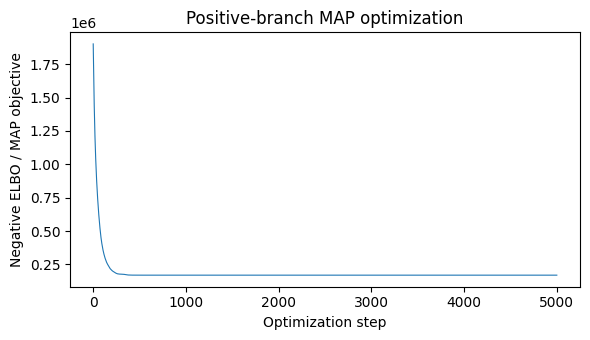

In [20]:
fig, ax = plt.subplots(figsize=(6.0, 3.5))

ax.plot(
    np.arange(positive_map_losses.size),
    positive_map_losses,
    lw=0.8,
)

ax.set_xlabel("Optimization step")
ax.set_ylabel("Negative ELBO / MAP objective")
ax.set_title("Positive-branch MAP optimization")

fig.tight_layout()
plt.show()


In [21]:
def physical_gains_from_guide(
    guide,
    params,
):
    """Recover physical complex gains from an AutoLaplace guide median."""
    sites = guide.median(params)

    fraction = np.asarray(
        sites["dipole_gain_fraction"],
        dtype=np.float32,
    )
    amplitude = N_DIPOLES * fraction

    relative_phase_unwrapped = np.asarray(
        sites["relative_phase_unwrapped"],
        dtype=np.float32,
    )
    relative_phase = np.angle(
        np.exp(1j * relative_phase_unwrapped)
    ).astype(np.float32)

    phase = np.concatenate(
        [
            np.zeros(1, dtype=np.float32),
            relative_phase,
        ]
    )

    gains = (
        amplitude
        * np.exp(1j * phase)
    ).astype(np.complex64)

    return gains, sites


positive_map_gains, positive_map_sites = physical_gains_from_guide(
    positive_map_guide,
    positive_map_params,
)

positive_map_s = float(
    symmetry_statistic(
        jnp.asarray(positive_map_gains)
    )
)

positive_map_model_db = np.asarray(
    predict_beam_db(
        jnp.asarray(positive_map_gains)
    )
)

positive_map_residual_db = (
    np.asarray(observed_db)
    - positive_map_model_db
)

print("Amplitude sum:", np.abs(positive_map_gains).sum())
print("S(g_MAP+):", f"{positive_map_s:+.6e}")
print(
    "Residual RMS:",
    f"{np.sqrt(np.mean(positive_map_residual_db**2)):.4f} dB",
)


Amplitude sum: 15.999999
S(g_MAP+): +2.172226e-06
Residual RMS: 3.0284 dB


In [22]:
# -------------------------------------------------------------------------
# Compare MAP and SMC initializers using the same physical-space
# log likelihood and priors.
# -------------------------------------------------------------------------

dirichlet_concentration = jnp.full(
    N_DIPOLES,
    DIRICHLET_ALPHA,
    dtype=jnp.float32,
)

phase_prior_mean = jnp.zeros(
    N_DIPOLES - 1,
    dtype=jnp.float32,
)

phase_prior_concentration = jnp.full(
    N_DIPOLES - 1,
    PHASE_KAPPA,
    dtype=jnp.float32,
)


def evaluate_physical_log_posterior(dipole_gains):
    dipole_gains = jnp.asarray(
        dipole_gains,
        dtype=jnp.complex64,
    )

    amplitude = jnp.abs(dipole_gains)

    fraction = (
        amplitude / jnp.sum(amplitude)
    )

    phase = jnp.angle(dipole_gains)

    relative_phase = jnp.angle(
        jnp.exp(
            1j * (
                phase[1:]
                - phase[0]
            )
        )
    )

    model_db = predict_beam_db(
        dipole_gains
    )

    log_likelihood = jnp.sum(
        dist.Normal(
            model_db,
            observed_sigma_db,
        ).log_prob(
            observed_db
        )
    )

    log_amplitude_prior = dist.Dirichlet(
        dirichlet_concentration
    ).log_prob(
        fraction
    )

    log_phase_prior = (
        dist.VonMises(
            phase_prior_mean,
            phase_prior_concentration,
        )
        .to_event(1)
        .log_prob(
            relative_phase
        )
    )

    log_prior = (
        log_amplitude_prior
        + log_phase_prior
    )

    return {
        "log_likelihood": float(log_likelihood),
        "log_prior": float(log_prior),
        "log_posterior": float(
            log_likelihood + log_prior
        ),
    }


map_scores = evaluate_physical_log_posterior(
    positive_map_gains
)

smc_scores = evaluate_physical_log_posterior(
    validation_positive_gains
)

print("Positive MAP")
print("------------")
for key, value in map_scores.items():
    print(f"{key:16s}: {value:.3f}")

print()

print("Best SMC particle")
print("-----------------")
for key, value in smc_scores.items():
    print(f"{key:16s}: {value:.3f}")

print()
print(
    "Delta log posterior (MAP - SMC):",
    map_scores["log_posterior"]
    - smc_scores["log_posterior"],
)

Positive MAP
------------
log_likelihood  : -169787.141
log_prior       : 51.549
log_posterior   : -169735.594

Best SMC particle
-----------------
log_likelihood  : -146536.812
log_prior       : 55.308
log_posterior   : -146481.500

Delta log posterior (MAP - SMC): -23254.09375


In [23]:
smc_map_guide = AutoLaplaceApproximation(
    positive_map_model,
    init_loc_fn=make_init_strategy(
        validation_positive_gains
    ),
)

smc_map_svi = SVI(
    positive_map_model,
    smc_map_guide,
    positive_map_optimizer,
    loss=Trace_ELBO(),
)

smc_map_result = smc_map_svi.run(
    jax.random.key(MAP_SEED),
    NUM_MAP_STEPS,
    observed_db=jnp.asarray(
        observed_db,
        dtype=jnp.float32,
    ),
    observed_sigma_db=jnp.asarray(
        observed_sigma_db,
        dtype=jnp.float32,
    ),
    progress_bar=True,
    stable_update=True,
)

smc_map_gains, _ = physical_gains_from_guide(
    smc_map_guide,
    smc_map_result.params,
)

smc_map_scores = evaluate_physical_log_posterior(
    smc_map_gains
)

print("Starting SMC log posterior:")
print(
    evaluate_physical_log_posterior(
        validation_positive_gains
    )["log_posterior"]
)

print("Optimized log posterior:")
print(
    smc_map_scores["log_posterior"]
)

print(
    "S(g):",
    float(
        symmetry_statistic(
            jnp.asarray(smc_map_gains)
        )
    ),
)

100%|██████████████████████████████████████████████████████████████████████████| 5000/5000 [00:12<00:00, 386.85it/s, init loss: 146526.0781, avg. loss [4751-5000]: 146522.2969]

Starting SMC log posterior:
-146481.5
Optimized log posterior:
-146478.578125
S(g): 6.899427944517811e-07


In [68]:
# -------------------------------------------------------------------------
# Global prior screening configuration.
# -------------------------------------------------------------------------

N_CANDIDATES = 1024
N_MAP_STARTS = 32

CANDIDATE_SEED = 111

# Short MAP runs are intended only to identify promising basins.
N_MAP_STEPS_SEARCH = 1_000
MAP_SEARCH_LEARNING_RATE = 1e-3
MAP_SEARCH_CLIP_NORM = 10.0

In [69]:
# -------------------------------------------------------------------------
# Draw candidate gain vectors from the full prior.
#
# No branch restriction is applied here.
# -------------------------------------------------------------------------

candidate_key = jax.random.PRNGKey(
    CANDIDATE_SEED
)

fraction_key, phase_key = jax.random.split(
    candidate_key
)

candidate_fraction = dist.Dirichlet(
    jnp.full(
        N_DIPOLES,
        DIRICHLET_ALPHA,
        dtype=jnp.float32,
    )
).sample(
    fraction_key,
    sample_shape=(N_CANDIDATES,),
)

candidate_relative_phase = (
    dist.VonMises(
        loc=jnp.zeros(
            N_DIPOLES - 1,
            dtype=jnp.float32,
        ),
        concentration=jnp.full(
            N_DIPOLES - 1,
            PHASE_KAPPA,
            dtype=jnp.float32,
        ),
    )
    .to_event(1)
    .sample(
        phase_key,
        sample_shape=(N_CANDIDATES,),
    )
)

candidate_amplitude = (
    N_DIPOLES
    * candidate_fraction
)

candidate_phase = jnp.concatenate(
    [
        jnp.zeros(
            (N_CANDIDATES, 1),
            dtype=jnp.float32,
        ),
        candidate_relative_phase,
    ],
    axis=1,
)

candidate_gains = (
    candidate_amplitude
    * jnp.exp(
        1j * candidate_phase
    )
).astype(jnp.complex64)

print(
    "Candidate gains:",
    candidate_gains.shape,
)

Candidate gains: (1024, 16)


In [70]:
# -------------------------------------------------------------------------
# Evaluate physical-space likelihood, prior, posterior, and S(g).
# -------------------------------------------------------------------------

dirichlet_distribution = dist.Dirichlet(
    jnp.full(
        N_DIPOLES,
        DIRICHLET_ALPHA,
        dtype=jnp.float32,
    )
)

phase_distribution = (
    dist.VonMises(
        loc=jnp.zeros(
            N_DIPOLES - 1,
            dtype=jnp.float32,
        ),
        concentration=jnp.full(
            N_DIPOLES - 1,
            PHASE_KAPPA,
            dtype=jnp.float32,
        ),
    )
    .to_event(1)
)

observed_db_jax = jnp.asarray(
    observed_db,
    dtype=jnp.float32,
)

observed_sigma_db_jax = jnp.asarray(
    observed_sigma_db,
    dtype=jnp.float32,
)


def score_one_candidate(
    dipole_gains,
    fraction,
    relative_phase,
):
    model_db = predict_beam_db(
        dipole_gains
    )

    log_likelihood = jnp.sum(
        dist.Normal(
            model_db,
            observed_sigma_db_jax,
        ).log_prob(
            observed_db_jax
        )
    )

    log_amplitude_prior = (
        dirichlet_distribution.log_prob(
            fraction
        )
    )

    log_phase_prior = (
        phase_distribution.log_prob(
            relative_phase
        )
    )

    log_prior = (
        log_amplitude_prior
        + log_phase_prior
    )

    log_posterior = (
        log_likelihood
        + log_prior
    )

    s_value = symmetry_statistic(
        dipole_gains
    )

    return (
        log_likelihood,
        log_prior,
        log_posterior,
        s_value,
    )


score_candidates = jax.jit(
    jax.vmap(
        score_one_candidate,
        in_axes=(0, 0, 0),
    )
)

In [55]:
(
    candidate_log_likelihood,
    candidate_log_prior,
    candidate_log_posterior,
    candidate_s,
) = score_candidates(
    candidate_gains,
    candidate_fraction,
    candidate_relative_phase,
)

candidate_log_likelihood = np.asarray(
    candidate_log_likelihood
)
candidate_log_prior = np.asarray(
    candidate_log_prior
)
candidate_log_posterior = np.asarray(
    candidate_log_posterior
)
candidate_s = np.asarray(
    candidate_s
)

print(
    "Positive-S candidates:",
    np.sum(candidate_s > 0),
)
print(
    "Negative-S candidates:",
    np.sum(candidate_s < 0),
)

print(
    "Best candidate log posterior:",
    candidate_log_posterior.max(),
)
print(
    "Best candidate log likelihood:",
    candidate_log_likelihood.max(),
)

Positive-S candidates: 502
Negative-S candidates: 522
Best candidate log posterior: -642135.1
Best candidate log likelihood: -642185.5


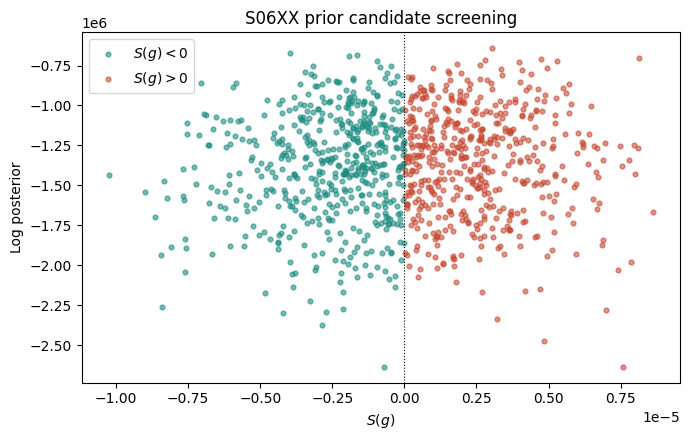

In [56]:
fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

positive = candidate_s > 0
negative = candidate_s < 0

ax.scatter(
    candidate_s[negative],
    candidate_log_posterior[negative],
    s=12,
    alpha=0.6,
    label=r"$S(g)<0$",
    color=cmr.wildfire([0.2]),
)

ax.scatter(
    candidate_s[positive],
    candidate_log_posterior[positive],
    s=12,
    alpha=0.6,
    label=r"$S(g)>0$",
    color=cmr.wildfire([0.8]),
)

ax.axvline(
    0.0,
    color="black",
    ls=":",
    lw=0.8,
)

ax.set_xlabel(r"$S(g)$")
ax.set_ylabel("Log posterior")
ax.set_title(
    f"{tilepol} prior candidate screening"
)
ax.legend()

fig.tight_layout()
plt.show()

In [57]:
# -------------------------------------------------------------------------
# Select the globally best candidates before applying symmetry.
# -------------------------------------------------------------------------

ranked_indices = np.argsort(
    candidate_log_posterior
)[::-1]

shortlist_indices = ranked_indices[
    :N_MAP_STARTS
]

print(
    "Shortlisted candidates"
)
print(
    "----------------------"
)

for rank, index in enumerate(
    shortlist_indices,
    start=1,
):
    print(
        f"{rank:2d}: "
        f"index={index:4d}, "
        f"logL={candidate_log_likelihood[index]:.1f}, "
        f"logP={candidate_log_posterior[index]:.1f}, "
        f"S={candidate_s[index]:+.3e}"
    )

Shortlisted candidates
----------------------
 1: index= 735, logL=-642185.5, logP=-642135.1, S=+3.030e-06
 2: index= 977, logL=-672528.2, logP=-672482.0, S=-3.977e-06
 3: index= 830, logL=-684077.0, logP=-684032.4, S=-1.649e-06
 4: index= 217, logL=-691732.4, logP=-691685.7, S=-1.930e-06
 5: index=  28, logL=-702513.9, logP=-702468.8, S=+8.139e-06
 6: index= 402, logL=-709168.0, logP=-709120.8, S=+4.745e-06
 7: index= 139, logL=-712694.9, logP=-712647.8, S=+2.804e-06
 8: index= 485, logL=-720298.6, logP=-720250.6, S=-9.348e-07
 9: index= 688, logL=-723698.8, logP=-723650.4, S=+5.281e-06
10: index= 969, logL=-726255.0, logP=-726206.9, S=+3.985e-06
11: index= 512, logL=-740166.5, logP=-740118.4, S=+1.817e-06
12: index=  98, logL=-744823.2, logP=-744777.3, S=+2.635e-06
13: index= 797, logL=-753277.8, logP=-753231.4, S=-4.813e-07
14: index= 867, logL=-754076.6, logP=-754030.7, S=-3.182e-06
15: index=  38, logL=-760660.6, logP=-760609.6, S=-8.348e-07
16: index= 451, logL=-763790.4, logP=-7

In [58]:
# -------------------------------------------------------------------------
# Map every shortlisted candidate onto the canonical S(g) > 0 branch.
# -------------------------------------------------------------------------

raw_shortlist_gains = np.asarray(
    candidate_gains
)[shortlist_indices]

canonical_gains = []

for gains in raw_shortlist_gains:
    s_value = float(
        symmetry_statistic(
            jnp.asarray(gains)
        )
    )

    if s_value > 0.0:
        canonical = gains
    elif s_value < 0.0:
        canonical = conjugate_rotate_gains(
            gains
        )
    else:
        raise RuntimeError(
            "Candidate lies on S(g) = 0."
        )

    canonical_gains.append(
        canonical
    )

canonical_gains = np.asarray(
    canonical_gains,
    dtype=np.complex64,
)

canonical_s = np.asarray(
    [
        float(
            symmetry_statistic(
                jnp.asarray(gains)
            )
        )
        for gains in canonical_gains
    ]
)

print(
    "Canonical S range:",
    canonical_s.min(),
    "to",
    canonical_s.max(),
)

if np.any(canonical_s <= 0.0):
    raise RuntimeError(
        "Canonicalization failed to place all candidates in S > 0."
    )

Canonical S range: 1.299670202570269e-07 to 8.138543307723012e-06


In [59]:
def gains_to_physical_parameters(
    dipole_gains,
):
    dipole_gains = np.asarray(
        dipole_gains,
        dtype=np.complex64,
    )

    amplitude = np.abs(
        dipole_gains
    )

    fraction = (
        amplitude
        / amplitude.sum()
    )

    phase = np.angle(
        dipole_gains
    )

    phase = np.angle(
        np.exp(
            1j
            * (
                phase
                - phase[0]
            )
        )
    )

    return (
        fraction.astype(np.float32),
        phase[1:].astype(np.float32),
    )

In [60]:
canonical_fraction = []
canonical_relative_phase = []

for gains in canonical_gains:
    fraction, relative_phase = (
        gains_to_physical_parameters(
            gains
        )
    )

    canonical_fraction.append(
        fraction
    )
    canonical_relative_phase.append(
        relative_phase
    )

canonical_fraction = jnp.asarray(
    canonical_fraction,
    dtype=jnp.float32,
)

canonical_relative_phase = jnp.asarray(
    canonical_relative_phase,
    dtype=jnp.float32,
)

(
    canonical_log_likelihood,
    canonical_log_prior,
    canonical_log_posterior,
    canonical_s_check,
) = score_candidates(
    jnp.asarray(
        canonical_gains,
        dtype=jnp.complex64,
    ),
    canonical_fraction,
    canonical_relative_phase,
)

canonical_log_likelihood = np.asarray(
    canonical_log_likelihood
)
canonical_log_prior = np.asarray(
    canonical_log_prior
)
canonical_log_posterior = np.asarray(
    canonical_log_posterior
)

In [61]:
print(
    "Raw -> canonical shortlist"
)
print(
    "--------------------------"
)

for rank, index in enumerate(
    shortlist_indices
):
    delta = (
        canonical_log_posterior[rank]
        - candidate_log_posterior[index]
    )

    print(
        f"{rank + 1:2d}: "
        f"raw S={candidate_s[index]:+.3e}, "
        f"raw logP={candidate_log_posterior[index]:.1f}, "
        f"canonical logP={canonical_log_posterior[rank]:.1f}, "
        f"delta={delta:+.1f}"
    )

Raw -> canonical shortlist
--------------------------
 1: raw S=+3.030e-06, raw logP=-642135.1, canonical logP=-642135.1, delta=+0.0
 2: raw S=-3.977e-06, raw logP=-672482.0, canonical logP=-672482.1, delta=-0.1
 3: raw S=-1.649e-06, raw logP=-684032.4, canonical logP=-684032.3, delta=+0.1
 4: raw S=-1.930e-06, raw logP=-691685.7, canonical logP=-691685.1, delta=+0.6
 5: raw S=+8.139e-06, raw logP=-702468.8, canonical logP=-702468.8, delta=+0.0
 6: raw S=+4.745e-06, raw logP=-709120.8, canonical logP=-709120.8, delta=+0.0
 7: raw S=+2.804e-06, raw logP=-712647.8, canonical logP=-712647.8, delta=+0.0
 8: raw S=-9.348e-07, raw logP=-720250.6, canonical logP=-720253.3, delta=-2.8
 9: raw S=+5.281e-06, raw logP=-723650.4, canonical logP=-723650.4, delta=+0.0
10: raw S=+3.985e-06, raw logP=-726206.9, canonical logP=-726206.9, delta=+0.0
11: raw S=+1.817e-06, raw logP=-740118.4, canonical logP=-740118.4, delta=+0.0
12: raw S=+2.635e-06, raw logP=-744777.3, canonical logP=-744777.3, delta=+0.

In [62]:
def run_short_map(
    initial_gains,
    *,
    rng_seed,
    num_steps=N_MAP_STEPS_SEARCH,
):
    """Run a short positive-branch MAP search from one physical gain vector."""

    # model = positive_branch_model
    model = unrestricted_model

    guide = AutoLaplaceApproximation(
        model,
        init_loc_fn=make_init_strategy(
            initial_gains
        ),
    )

    optimizer = ClippedAdam(
        step_size=MAP_SEARCH_LEARNING_RATE,
        clip_norm=MAP_SEARCH_CLIP_NORM,
    )

    svi = SVI(
        model,
        guide,
        optimizer,
        loss=Trace_ELBO(),
    )

    result = svi.run(
        jax.random.PRNGKey(
            rng_seed
        ),
        num_steps,
        observed_db=observed_db_jax,
        observed_sigma_db=observed_sigma_db_jax,
        progress_bar=False,
        stable_update=True,
    )

    gains, _ = physical_gains_from_guide(
        guide,
        result.params,
    )

    scores = evaluate_physical_log_posterior(
        gains
    )

    return {
        "gains": gains,
        "scores": scores,
        "losses": np.asarray(
            result.losses
        ),
        "guide": guide,
        "params": result.params,
    }

In [63]:
map_search_results = []

for start_index, gains in enumerate(
    canonical_gains
):
    result = run_short_map(
        gains,
        rng_seed=1_000 + start_index,
    )

    map_search_results.append(
        result
    )

    print(
        f"Start {start_index:02d}: "
        f"logP={result['scores']['log_posterior']:.1f}, "
        f"S={float(symmetry_statistic(jnp.asarray(result['gains']))):+.3e}"
    )

Start 00: logP=-171083.8, S=+2.490e-06
Start 01: logP=-162267.5, S=+2.021e-06
Start 02: logP=-180614.2, S=+1.644e-06
Start 03: logP=-213237.3, S=+1.251e-06
Start 04: logP=-194717.4, S=+1.946e-06
Start 05: logP=-197109.7, S=-6.719e-07
Start 06: logP=-215220.6, S=+2.050e-07
Start 07: logP=-182313.6, S=-1.514e-06
Start 08: logP=-166501.7, S=+1.746e-06
Start 09: logP=-153080.7, S=+1.204e-06
Start 10: logP=-153628.0, S=+7.515e-07
Start 11: logP=-167731.2, S=+2.791e-06
Start 12: logP=-210754.2, S=+1.905e-06
Start 13: logP=-197481.8, S=+7.718e-07
Start 14: logP=-180935.5, S=+1.089e-07
Start 15: logP=-201876.1, S=+8.538e-07
Start 16: logP=-176764.7, S=+1.244e-06
Start 17: logP=-176715.7, S=+2.162e-06
Start 18: logP=-170571.4, S=+6.989e-07
Start 19: logP=-154925.9, S=+4.293e-07
Start 20: logP=-161517.0, S=+8.177e-07
Start 21: logP=-169424.6, S=-1.599e-06
Start 22: logP=-213893.7, S=-8.372e-07
Start 23: logP=-168571.8, S=-2.807e-06
Start 24: logP=-172289.2, S=+2.462e-06
Start 25: logP=-166238.5,

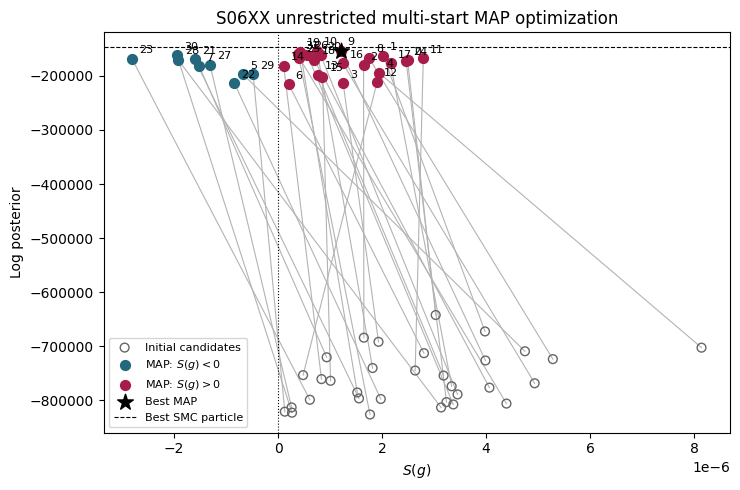

Best unrestricted MAP
---------------------
Start:         9
log posterior: -153080.7
S(g):          +1.203966e-06


In [72]:
# -------------------------------------------------------------------------
# Visualize unrestricted multi-start MAP optimization in
# (S, log posterior) space.
#
# Initial points come from canonical_gains.
# Final points come from map_search_results.
# -------------------------------------------------------------------------

initial_s = np.asarray(
    [
        float(
            symmetry_statistic(
                jnp.asarray(gains)
            )
        )
        for gains in canonical_gains
    ]
)

initial_scores = [
    evaluate_physical_log_posterior(
        gains
    )
    for gains in canonical_gains
]

initial_logp = np.asarray(
    [
        scores["log_posterior"]
        for scores in initial_scores
    ]
)

final_s = np.asarray(
    [
        float(
            symmetry_statistic(
                jnp.asarray(
                    result["gains"]
                )
            )
        )
        for result in map_search_results
    ]
)

final_logp = np.asarray(
    [
        result["scores"]["log_posterior"]
        for result in map_search_results
    ]
)

best_index = np.argmax(
    final_logp
)


fig, ax = plt.subplots(
    figsize=(7.5, 5.0)
)

# Connect each initial candidate to its optimized MAP solution.
for i in range(
    len(map_search_results)
):
    ax.plot(
        [
            initial_s[i],
            final_s[i],
        ],
        [
            initial_logp[i],
            final_logp[i],
        ],
        color="0.7",
        lw=0.8,
        zorder=1,
    )

# Initial candidates.
ax.scatter(
    initial_s,
    initial_logp,
    marker="o",
    s=40,
    facecolors="none",
    edgecolors="0.4",
    label="Initial candidates",
    zorder=2,
)

# Final MAP solutions, colored by branch.
negative = final_s < 0
positive = final_s > 0

ax.scatter(
    final_s[negative],
    final_logp[negative],
    s=50,
    color=cmr.pride(0.2),
    label=r"MAP: $S(g)<0$",
    zorder=3,
)

ax.scatter(
    final_s[positive],
    final_logp[positive],
    s=50,
    color=cmr.pride(0.8),
    label=r"MAP: $S(g)>0$",
    zorder=3,
)

# Highlight the best MAP solution.
ax.scatter(
    final_s[best_index],
    final_logp[best_index],
    s=140,
    marker="*",
    color="black",
    label="Best MAP",
    zorder=4,
)

# Label final MAP points by start number.
for i, (
    s_value,
    logp,
) in enumerate(
    zip(
        final_s,
        final_logp,
    )
):
    ax.annotate(
        str(i),
        (
            s_value,
            logp,
        ),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

# Symmetry boundary.
ax.axvline(
    0.0,
    color="black",
    ls=":",
    lw=0.8,
)

# Known SMC benchmark during development.
ax.axhline(
    -146481.5,
    color="black",
    ls="--",
    lw=0.8,
    label="Best SMC particle",
)

ax.set_xlabel(
    r"$S(g)$"
)
ax.set_ylabel(
    "Log posterior"
)
ax.set_title(
    f"{tilepol} unrestricted multi-start MAP optimization"
)

ax.legend(
    fontsize=8
)

fig.tight_layout()
plt.show()


print(
    "Best unrestricted MAP"
)
print(
    "---------------------"
)
print(
    f"Start:         "
    f"{best_index}"
)
print(
    f"log posterior: "
    f"{final_logp[best_index]:.1f}"
)
print(
    f"S(g):          "
    f"{final_s[best_index]:+.6e}"
)

In [67]:
map_log_posterior = np.asarray(
    [
        result["scores"]["log_posterior"]
        for result in map_search_results
    ]
)

best_map_index = int(
    np.argmax(
        map_log_posterior
    )
)

best_positive_map_gains = (
    map_search_results[
        best_map_index
    ]["gains"]
)

print()
print(
    "Best short-MAP start:",
    best_map_index,
)
print(
    "Best log posterior:",
    map_log_posterior[
        best_map_index
    ],
)
print(
    "Best S(g):",
    float(
        symmetry_statistic(
            jnp.asarray(
                best_positive_map_gains
            )
        )
    ),
)


Best short-MAP start: 9
Best log posterior: -153080.734375
Best S(g): 1.203966348839458e-06


In [73]:
# -------------------------------------------------------------------------
# Second-stage MAP refinement of the best short-MAP solutions.
# -------------------------------------------------------------------------

N_MAP_REFINEMENTS = 8
N_MAP_STEPS_REFINEMENT = 5_000

MAP_REFINEMENT_LEARNING_RATE = 2e-4
MAP_REFINEMENT_CLIP_NORM = 10.0

MAP_REFINEMENT_SEED = 2_000


# Rank the short-MAP solutions by their physical log posterior.
short_map_logp = np.asarray(
    [
        result["scores"]["log_posterior"]
        for result in map_search_results
    ]
)

refinement_indices = np.argsort(
    short_map_logp
)[::-1][:N_MAP_REFINEMENTS]

print("Selected short-MAP solutions for refinement")
print("------------------------------------------")

for rank, index in enumerate(
    refinement_indices,
    start=1,
):
    gains = map_search_results[index]["gains"]

    print(
        f"{rank:2d}: "
        f"start={index:2d}, "
        f"logP={short_map_logp[index]:.1f}, "
        f"S={float(symmetry_statistic(jnp.asarray(gains))):+.3e}"
    )

Selected short-MAP solutions for refinement
------------------------------------------
 1: start= 9, logP=-153080.7, S=+1.204e-06
 2: start=10, logP=-153628.0, S=+7.515e-07
 3: start=19, logP=-154925.9, S=+4.293e-07
 4: start=31, logP=-160162.7, S=+3.903e-07
 5: start=26, logP=-160876.8, S=+5.629e-07
 6: start=20, logP=-161517.0, S=+8.177e-07
 7: start=30, logP=-161808.4, S=-1.944e-06
 8: start= 1, logP=-162267.5, S=+2.021e-06


In [74]:
def run_map_refinement(
    initial_gains,
    *,
    rng_seed,
    num_steps=N_MAP_STEPS_REFINEMENT,
):
    """Run a longer, lower-learning-rate unrestricted MAP refinement."""

    guide = AutoLaplaceApproximation(
        unrestricted_model,
        init_loc_fn=make_init_strategy(
            initial_gains
        ),
    )

    optimizer = ClippedAdam(
        step_size=MAP_REFINEMENT_LEARNING_RATE,
        clip_norm=MAP_REFINEMENT_CLIP_NORM,
    )

    svi = SVI(
        unrestricted_model,
        guide,
        optimizer,
        loss=Trace_ELBO(),
    )

    result = svi.run(
        jax.random.PRNGKey(rng_seed),
        num_steps,
        observed_db=observed_db_jax,
        observed_sigma_db=observed_sigma_db_jax,
        progress_bar=False,
        stable_update=True,
    )

    gains, sites = physical_gains_from_guide(
        guide,
        result.params,
    )

    scores = evaluate_physical_log_posterior(
        gains
    )

    return {
        "gains": gains,
        "sites": sites,
        "scores": scores,
        "losses": np.asarray(
            result.losses
        ),
        "guide": guide,
        "params": result.params,
    }

In [75]:
map_refinement_results = []

for refinement_rank, short_map_index in enumerate(
    refinement_indices
):
    initial_gains = (
        map_search_results[
            short_map_index
        ]["gains"]
    )

    result = run_map_refinement(
        initial_gains,
        rng_seed=(
            MAP_REFINEMENT_SEED
            + refinement_rank
        ),
    )

    map_refinement_results.append(
        {
            "short_map_index": short_map_index,
            **result,
        }
    )

    refined_s = float(
        symmetry_statistic(
            jnp.asarray(
                result["gains"]
            )
        )
    )

    print(
        f"Refinement {refinement_rank:02d} "
        f"(short start {short_map_index:02d}): "
        f"logP={result['scores']['log_posterior']:.1f}, "
        f"S={refined_s:+.3e}"
    )

Refinement 00 (short start 09): logP=-153079.2, S=+1.211e-06
Refinement 01 (short start 10): logP=-153624.0, S=+7.432e-07
Refinement 02 (short start 19): logP=-154924.7, S=+4.255e-07
Refinement 03 (short start 31): logP=-160160.5, S=+3.838e-07
Refinement 04 (short start 26): logP=-160874.0, S=+5.669e-07
Refinement 05 (short start 20): logP=-161515.3, S=+8.297e-07
Refinement 06 (short start 30): logP=-161807.0, S=-1.940e-06
Refinement 07 (short start 01): logP=-162265.0, S=+2.016e-06


In [76]:
refined_logp = np.asarray(
    [
        result["scores"]["log_posterior"]
        for result in map_refinement_results
    ]
)

best_refinement_index = int(
    np.argmax(
        refined_logp
    )
)

best_refinement = (
    map_refinement_results[
        best_refinement_index
    ]
)

best_map_gains = (
    best_refinement["gains"]
)

best_map_s = float(
    symmetry_statistic(
        jnp.asarray(
            best_map_gains
        )
    )
)

print()
print("Best refined MAP")
print("----------------")
print(
    "Short-MAP source:",
    best_refinement[
        "short_map_index"
    ],
)
print(
    "Log posterior:",
    best_refinement[
        "scores"
    ]["log_posterior"],
)
print(
    "Log likelihood:",
    best_refinement[
        "scores"
    ]["log_likelihood"],
)
print(
    "Log prior:",
    best_refinement[
        "scores"
    ]["log_prior"],
)
print(
    "S(g):",
    best_map_s,
)


Best refined MAP
----------------
Short-MAP source: 9
Log posterior: -153079.21875
Log likelihood: -153134.828125
Log prior: 55.61650085449219
S(g): 1.2112794820495765e-06


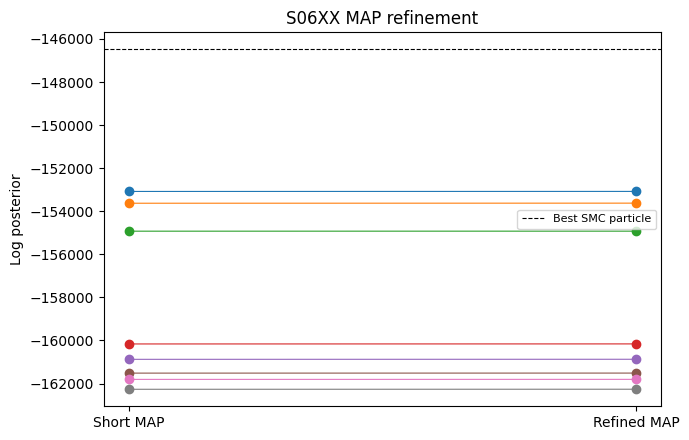

In [77]:
initial_refinement_logp = np.asarray(
    [
        short_map_logp[
            result["short_map_index"]
        ]
        for result in map_refinement_results
    ]
)

fig, ax = plt.subplots(
    figsize=(7.0, 4.5)
)

for i in range(
    N_MAP_REFINEMENTS
):
    ax.plot(
        [0, 1],
        [
            initial_refinement_logp[i],
            refined_logp[i],
        ],
        marker="o",
        lw=0.8,
    )

ax.axhline(
    -146481.5,
    color="black",
    ls="--",
    lw=0.8,
    label="Best SMC particle",
)

ax.set_xticks(
    [0, 1],
    [
        "Short MAP",
        "Refined MAP",
    ],
)

ax.set_ylabel(
    "Log posterior"
)
ax.set_title(
    f"{tilepol} MAP refinement"
)

ax.legend(
    fontsize=8
)

fig.tight_layout()
plt.show()

## 12. Opposite-branch MAP and NUTS

Once $\widehat g_+$ is a satisfactory positive-branch MAP estimate:

1. initialize positive-branch NUTS at $\widehat g_+$;
2. generate $T(\widehat g_+)$ with `conjugate_rotate_gains`;
3. use that transformed point to initialize a **negative-branch MAP optimization**;
4. let the negative MAP move away from the exact symmetry prediction to accommodate
   real data asymmetries;
5. initialize negative-branch NUTS at the resulting $\widehat g_-$.

The two NUTS runs then characterize

$$
p(g\mid D,S>0)
\qquad\text{and}\qquad
p(g\mid D,S<0)
$$

independently.

This sequence should only be implemented after the generic-seed positive MAP search
is demonstrated to converge reliably.

In [ ]:
# Planned next step after validating positive_map_gains:
#
# positive_nuts = run_nuts(
#     positive_branch_model,
#     positive_map_gains,
#     rng_seed=101,
#     num_warmup=1000,
#     num_samples=2000,
# )
#
# negative_map_seed = conjugate_rotate_gains(
#     positive_map_gains
# )
#
# Then run an analogous negative-branch MAP optimization from negative_map_seed
# before launching negative-branch NUTS.


# Part IV — Relative branch mass with a Laplace approximation

## 8. Target quantity

Sampling the two branches independently gives their local posterior shapes, but it
does not by itself tell us their relative posterior probability.

Let the unnormalized posterior mass of each branch be

$$
Z_+
=
\int_{S(g)>0}
p(D\mid g)\,p(g)\,dg,
$$

and

$$
Z_-
=
\int_{S(g)<0}
p(D\mid g)\,p(g)\,dg.
$$

Then

$$
\frac{P(S>0\mid D)}{P(S<0\mid D)}
=
\frac{Z_+}{Z_-}.
$$

A first approximation to this ratio can be obtained locally around each posterior
mode using a Laplace approximation.

For branch $k$, with mode $\hat\theta_k$ in an unconstrained real parameterization,

$$
\log Z_k
\approx
\log p(D,\hat\theta_k)
+
\frac{d}{2}\log(2\pi)
-
\frac{1}{2}\log\det\mathcal H_k,
$$

where $\mathcal H_k$ is the Hessian of the negative log joint density at the mode.

For the ratio of two branches with the same dimension, the common
$\frac d2\log(2\pi)$ term cancels:

$$
\log\frac{Z_+}{Z_-}
\approx
\log p(D,\hat\theta_+)
-
\log p(D,\hat\theta_-)
-
\frac12
\left[
\log\det\mathcal H_+
-
\log\det\mathcal H_-
\right].
$$

This accounts for both the difference in peak posterior density and the local volume
of each mode.

The Laplace approximation should initially be treated as a diagnostic. Its accuracy
can later be checked against a more robust evidence estimator if necessary.

## 14. Current development status

### Established

- [x] refactored AEE model uses post-current complex dipole gains;
- [x] derived the conjugate + \(180^\circ\)-rotation degeneracy;
- [x] defined \(S(g)\) with \(S(Tg)=-S(g)\);
- [x] SMC posteriors show clean separation by the sign of \(S(g)\);
- [x] branch-conditioned NUTS is healthy when initialized inside a posterior mode;
- [x] conjugate rotation provides an excellent initializer for the opposite branch.

### Next

- [ ] obtain a reliable positive-branch MAP from a generic asymmetric seed;
- [ ] if Adam/SVI is insufficient, replace the optimizer with L-BFGS;
- [ ] use MAP estimates to initialize production NUTS runs on both branches;
- [ ] run multi-chain convergence diagnostics within each branch;
- [ ] compute Hessians at the two branch MAP estimates;
- [ ] evaluate the Laplace log-mass ratio;
- [ ] compare NUTS branch posteriors and Laplace weights against SMC as validation;
- [ ] remove the SMC-dependent validation section from the final production notebook.

The intended final workflow contains **no SMC dependency**.